# Study of population & spectrum peaks imabalnce, out of resonance.
## Population study
1. Plot populations of $\ket{+}$ and $\ket{-}$ Vs. $\omega_{THz}$ for different $\Delta_q$
2. Comparision with analytical results
3. Turn it into a map for a bigger set of $Delta_q$

## Spectrum study
1. Plot spectrum ratio for different $\Delta_q$
2. Extract area for left and right peaks
3. Comparision of numerical and analytical results for the area ratio

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from matplotlib import rc

# Font and LaTeX config (para las gráficas, que queden estilo 'paper')
rc('font', **{'family': 'serif', 'serif': ['Helvetica']})
rc('text', usetex=True)


from tqdm.notebook import tqdm

Parameters

In [55]:
kappa_b = 1 #decay en la cav de THz
gamma = 1e-4 * kappa_b # decay en el qubit

chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Nb = 3         # segunda cavidad

w_THz_list = np.linspace(0, 400, 91)


# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(0, 1.1*Omega, 6)
# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, 91)

Operators

In [56]:
sx = tensor(sigmax(), qeye(Nb))
sz = tensor(sigmaz(), qeye(Nb))
sm = tensor(sigmam(), qeye(Nb))

b = tensor(qeye(2), destroy(Nb))
b_dag = b.dag()

# Disipadores
D_with = [
    np.sqrt(gamma) * sm,
    np.sqrt(kappa_b) * b
]

num_Pplus_matrix = np.zeros((len(Delta_q_list),len(w_THz_list)))

# 1. Population imbalance graphs

### 1.1:  Numerical calculation

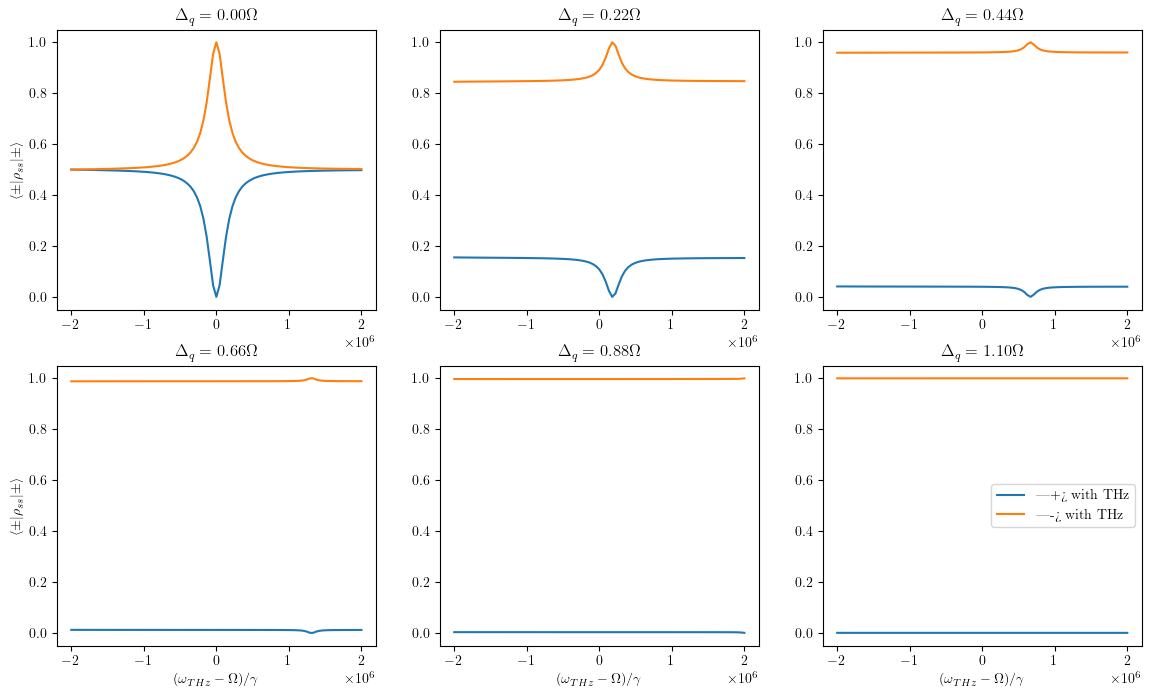

Text(0.5, 0.98, 'Dressed-states population imbalance$')

<Figure size 640x480 with 0 Axes>

In [57]:
figPops, axPops = plt.subplots(2,3, figsize=(14,8))
axPops = axPops.flatten()

nrows, ncols = 2, 3

for idx, Delta_q in enumerate(Delta_q_list):
    # vectors where we store the population @ each w_b
    pops_plus = []
    pops_minus = []
    axP = axPops[idx]
    x_axis = w_THz_list - Omega* np.ones(len(w_THz_list))

    for w_b in w_THz_list:

        H_qubit = (Omega/2)*sigmax() + Delta_q*sigmaz()
        eigvals, eigstates = H_qubit.eigenstates()

        plus_state = eigstates[1]  # mayor energía
        minus_state = eigstates[0] #menor energía

        # extender al espacio total
        plus = tensor(eigstates[1], qeye(Nb))
        P_plus = plus * plus.dag()

        minus = tensor(eigstates[0], qeye(Nb))
        P_minus = minus * minus.dag()

        H = (Omega/2)*sx + Delta_q * sz + w_b * b_dag * b + chi * (sz + 1) * (b + b_dag)

        rho_ss_with = steadystate(H, D_with)
        pop_plus= expect(P_plus, rho_ss_with)
        pop_minus = expect(P_minus, rho_ss_with)

        pops_minus.append(pop_minus)
        pops_plus.append(pop_plus)

    num_Pplus_matrix[idx,:] = pops_plus
    # =========================
    # Gráficas
    # =========================

    axP.plot(x_axis/gamma, pops_plus, label="|+> with THz")
    axP.plot(x_axis/gamma, pops_minus, label="|-> with THz")

    axP.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
    #axP.set_title(rf"$\Delta_q = {Delta_q/kappa_b:.2f}\Kappa_b$")
     # ---------------------------
    # 1) ylabel solo primera columna
    # ---------------------------
    if idx % ncols == 0:
        axP.set_ylabel(r"$\langle \pm | \rho_{ss} | \pm \rangle$")
    else:
        axP.set_ylabel("")

    # ---------------------------
    # 2) xlabel solo última fila
    # ---------------------------
    if idx // ncols == nrows - 1:
        axP.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
    else:
        axP.set_xlabel("")

    # ---------------------------
    # 3) leyenda solo último panel
    # ---------------------------
    if idx == len(axPops) - 1:
        axP.legend()

plt.show()
plt.tight_layout()
figPops.suptitle(r"Dressed-states population imbalance$", fontsize=14)


### 1.2: analytical $\langle \xi^\dagger \xi \rangle$ for the different $\Delta_q $.

$$\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega^2}{4} }$$
$$h = \frac{\Omega_R - 2\Delta_q}{\Omega}\longrightarrow \theta\equiv arctan(h)$$
with $\theta\in[0,\pi/4]$


In [58]:
# Firts of all: define the theta angles for each Delta_q
theta_list = np.zeros(len(Delta_q_list))
for idx, Delta_q in enumerate(Delta_q_list):
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)
    theta_list[idx] = theta

print(theta_list)

[0.78539816 0.57814473 0.42457074 0.32416599 0.25834757 0.21331375]


Now, for the analytical expression of $\langle \xi^\dagger \xi \rangle$ we had arrived at:
$$ \langle \xi^\dagger \xi \rangle  = \frac{\gamma\sin^4\theta}{\gamma\cos^4\theta + \gamma\sin^4\theta + \Gamma_P}$$

where $\Gamma_P$ is the Purcell factor, given by: $\Gamma_P = \frac{g^2\gamma}{(\omega_b-\Omega)^2+\gamma^2/4}$, with $g=2\chi\cos\theta\sin\theta$.

### 1.3: Comparision. Numerical Vs Analytical

0.7853981633974483
0.5781447261050553
0.4245707379650676
0.3241659945436302
0.2583475693811388
0.2133137465634381


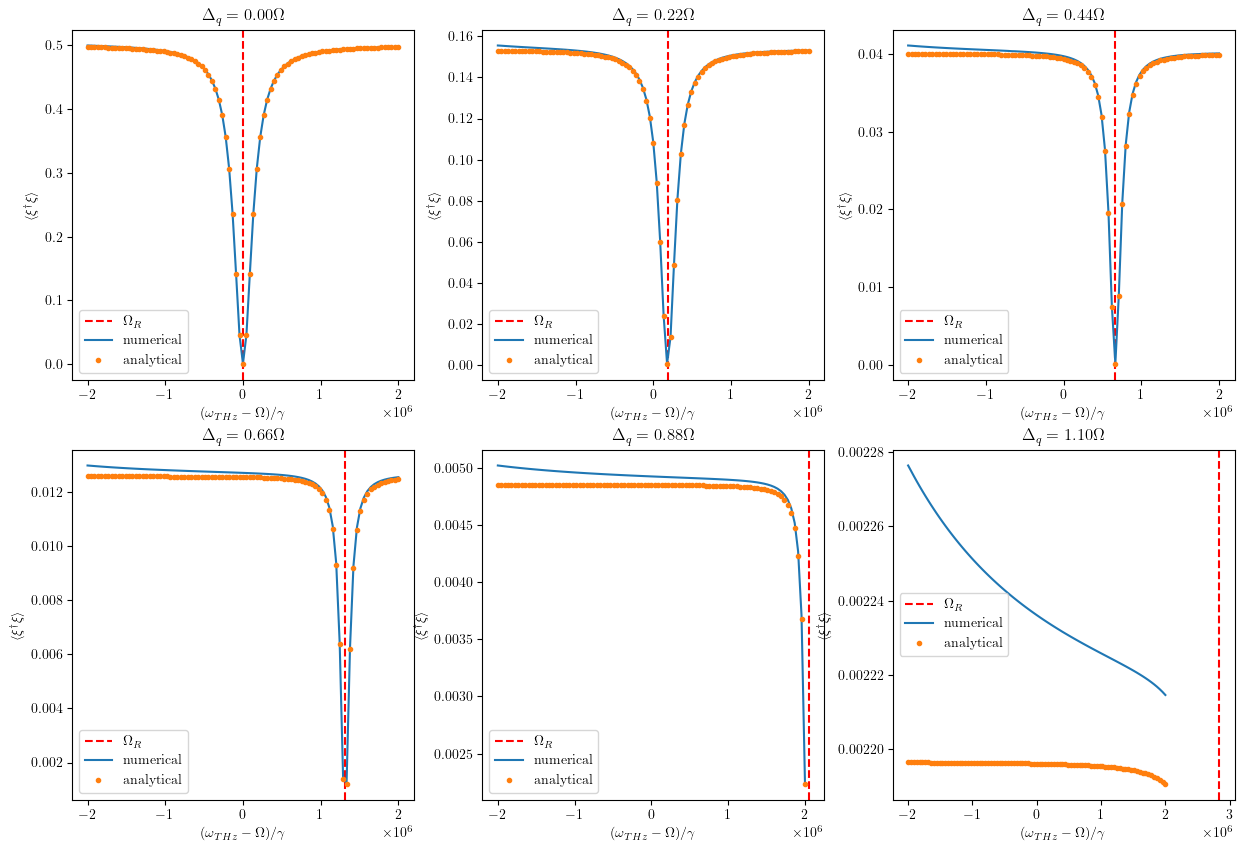

Text(0.5, 0.98, 'Numerical Vs. analytical population imbalance')

<Figure size 640x480 with 0 Axes>

In [59]:
figN, axesN= plt.subplots(2,3, figsize = (15,10))
axesN = axesN.flatten()

an_Pplus_matrix = np.zeros((len(Delta_q_list),len(w_THz_list)))

for idx1, Delta_q in enumerate(Delta_q_list):
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)
        
    pops_plus = num_Pplus_matrix[idx1,:] # parte calculada numéricamente

    print(theta)
    axN = axesN[idx1]

    cos = np.sin(theta)
    sin = np.cos(theta)
    g_eff = 2*chi*sin*cos # acoplo efectivo
    
    pump =  gamma* cos**4
    decay = gamma * sin**4
    P_plus_an = np.zeros(len(w_THz_list))
    
    for idx, w_b in enumerate(w_THz_list):
        Purcell = g_eff**2*kappa_b / ( (w_b-Omega_R)**2 + kappa_b**2/4 ) 
        P_plus_an[idx] = pump/(pump + decay + Purcell)
        an_Pplus_matrix[idx1,idx] = pump/(pump + decay + Purcell)


    
    # Add vertical line at Omega_R
    axN.axvline((Omega_R-Omega)/gamma, color='r', linestyle='--', label=r'$\Omega_R$')
    axN.plot(x_axis/gamma, pops_plus, label = 'numerical')
    axN.plot(x_axis/gamma, P_plus_an,'.', label = 'analytical')

    axN.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")

    # ---------------------------
    # 1) ylabel solo primera columna
    # ---------------------------
    if idx % ncols == 0:
        axN.set_ylabel(r"$\langle \xi^\dagger\xi \rangle$")
    else:
        axN.set_ylabel("")

   
    axN.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")

    axN.legend()

plt.show()
plt.tight_layout()
figN.suptitle(r"Numerical Vs. analytical population imbalance", fontsize=14)

# 2. Spectra
- First of all: draw the spectra at different $\Delta_q$ to identify where we perform the lorentzian fit of each peak. 
Map of S(Delta_a, w_b) for each Delta_q
- Perform the fit
- numerical vs analytical calculation

Now we have to expand the Hilbert space, to include the sensor

In [60]:
kappa_a = 1
g = 0.001       # acoplo qubit con el sensor
Na = 2        # truncación de la primera cavidad 

# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Omega_R = 2*np.sqrt(Delta_q**2+(Omega/2)**2)

### 2.1 Complete spectrum figures at different $\Delta_q$

Calculating spectra:   0%|          | 0/6 [00:00<?, ?it/s]

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 50000.

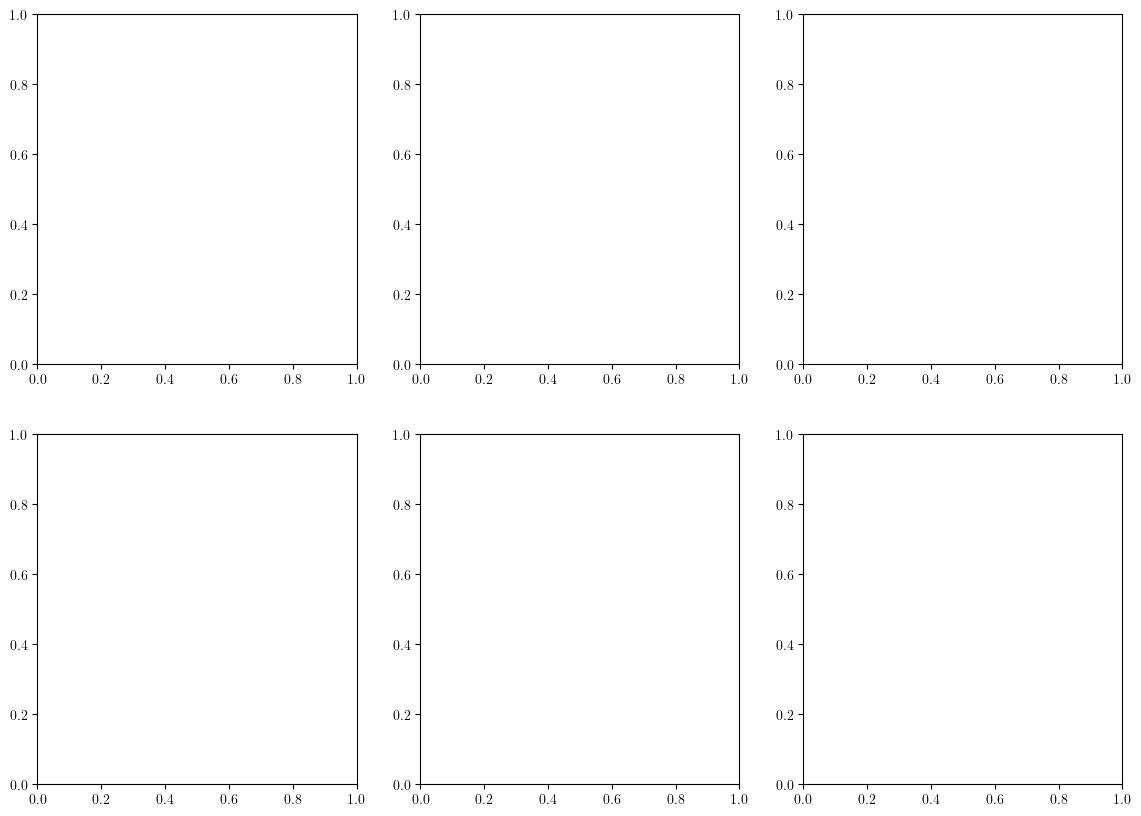

In [61]:
figN, axesN= plt.subplots(2,3, figsize = (14,10))
axesN = axesN.flatten()

H0 =  (Omega/2) * sx \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) 

# rango para calcular el área del espectro
Delta_a_list = np.linspace(-3*Omega, 3*Omega, 49)

def lorentzian(x, A, x0, gamma):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

def mollow_spectrum(x,
                    A0, x0, gamma0,
                    A_L, xL, gammaL,
                    A_R, xR, gammaR,
                    C):
    
    central = lorentzian(x, A0, x0, gamma0)
    left = lorentzian(x, A_L, xL, gammaL)
    right = lorentzian(x, A_R, xR, gammaR)

    return central + left + right + C

for idx1, Delta_q in enumerate(tqdm(Delta_q_list, desc="Calculating spectra")):
    
    P_plus = an_Pplus_matrix[idx1,:]

    H1 = H0 + Delta_q * sz

    areas_num_ratio = np.zeros((len(w_THz_list)))
    areas_anan_ratio = np.zeros(( len(w_THz_list)))

    for idx, w_b in enumerate(w_THz_list):

        H2 = H1 + w_b * b_plus * b

        spectrum = []

        for Delta_a in Delta_a_list:
            H = H2 + Delta_a * a_plus * a
            rho_SS = steadystate(H, Dissipators)
            spectrum.append(expect(a_plus * a, rho_SS))

        spectrum = np.array(spectrum)

        
        # -------------------------
        # guesses iniciales
        # -------------------------

        C0 = np.min(spectrum)

        # pico central
        A0 = np.max(spectrum) - C0
        x0 = Delta_a_list[np.argmax(spectrum)]
        gamma0 = Omega_R/10

        # picos laterales
        xL = -Omega_R
        xR = Omega_R

        AL = A0/3
        AR = A0/3

        gammaL = Omega_R/10
        gammaR = Omega_R/10


        p0 = [
            A0, x0, gamma0,
            AL, xL, gammaL,
            AR, xR, gammaR,
            C0
        ]


    
        popt, pcov = curve_fit(
            mollow_spectrum,
            Delta_a_list,
            spectrum,
            p0=p0,
            maxfev=50000
        )


        (
        A0_fit, x0_fit, gamma0_fit,
        AL_fit, xL_fit, gammaL_fit,
        AR_fit, xR_fit, gammaR_fit,
        C_fit
        ) = popt


        # áreas de cada Lorentziana
        area_L = np.pi * AL_fit * np.abs(gammaL_fit)
        area_R = np.pi * AR_fit * np.abs(gammaR_fit)
        area_0 = np.pi * A0_fit * np.abs(gamma0_fit)

        ratio = area_R/area_L


        areas_num_ratio[idx] = ratio
        areas_anan_ratio[idx] = sin**4 * P_plus[idx]/( cos**4 * (1- P_plus[idx]))

    axN.plot(x_axis/gamma, areas_num_ratio, label = 'numerical')
    axN.plot(x_axis/gamma, areas_anan_ratio,'.', label = 'analytical')
    # Add vertical line at Omega_R
    axN.axvline((Omega_R-Omega)/gamma, color='r', linestyle='--', label=r'$\Omega_R$')
    
    axN.set_title(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")

    # ---------------------------
    # 1) ylabel solo primera columna
    # ---------------------------
    if idx % ncols == 0:
        axN.set_ylabel(r"$\langle \xi^\dagger\xi \rangle$")
    else:
        axN.set_ylabel("")

    # ---------------------------
    # 2) xlabel solo última fila
    # ---------------------------
    if idx // ncols == nrows - 1:
        axN.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
    else:
        axN.set_xlabel("")

    # ---------------------------
    # 3) leyenda solo último panel
    # ---------------------------
    if idx == 5:
        axN.legend()

plt.show()
plt.tight_layout()
figN.suptitle(r"Numerical Vs. analytical right-to-left spectral area ratio", fontsize=14)